# Finding Complex Roots

Finding imaginary roots by treating real and imaginary parts as separate dimensions.

**Example:** $x^3 - x^2 + x - 1 = 0$ with roots at $x = 1, \pm i$.

## System Information

This section documents the computational environment used to run this notebook.

In [1]:
import sys
import platform
import time
import psutil
import os

print("System Information")
print("=" * 70)
print(f"Python version: {sys.version}")
print(f"Platform: {platform.platform()}")
print(f"Processor: {platform.processor()}")
print(f"CPU count: {psutil.cpu_count(logical=False)} physical, {psutil.cpu_count(logical=True)} logical")
print(f"Total memory: {psutil.virtual_memory().total / (1024**3):.2f} GB")
print("=" * 70)

# Key package versions
print("\nKey Library Versions:")
print("-" * 70)
packages = [
    ('numpy', 'np'),
    ('scipy', 'scipy'),
    ('matplotlib', 'matplotlib'),
    ('sklearn', 'sklearn'),
    ('torch', 'torch'),
    ('gmr', 'gmr'),
]

for pkg_name, import_name in packages:
    try:
        mod = __import__(pkg_name)
        version = getattr(mod, '__version__', 'unknown')
        print(f"{pkg_name:<20} {version}")
    except ImportError:
        print(f"{pkg_name:<20} NOT INSTALLED")

print("-" * 70)

# Initialize timing and memory tracking
_start_time = time.time()
_process = psutil.Process(os.getpid())
_start_memory_mb = _process.memory_info().rss / (1024 * 1024)

print(f"\nNotebook execution started: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_start_time))}")
print(f"Initial memory usage: {_start_memory_mb:.2f} MB")
print("=" * 70)

System Information
Python version: 3.12.11 (main, Jun 12 2025, 12:22:42) [Clang 20.1.4 ]
Platform: macOS-15.6.1-arm64-arm-64bit
Processor: arm
CPU count: 14 physical, 14 logical
Total memory: 64.00 GB

Key Library Versions:
----------------------------------------------------------------------
numpy                2.3.5
scipy                1.16.3
matplotlib           3.10.7


sklearn              1.6.1


torch                2.7.1
gmr                  2.0.2
----------------------------------------------------------------------

Notebook execution started: 2025-12-18 08:14:36
Initial memory usage: 331.27 MB


## System Information

This section documents the computational environment used to run this notebook.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings

# Configure JAX to use CPU (avoids GPU/XLA compatibility issues)
import os
os.environ['JAX_PLATFORMS'] = 'cpu'

# Import reusable utilities from local module
from generative_optimization import (
    generate_samples,
    estimate_sample_size,
    best_gmm,
    best_gmm_bic,
    cluster_stats,
    validate_gmm
)

# Figure settings
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor'] = 'white'
mpl.rcParams['figure.dpi'] = 150

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore', category=RuntimeWarning)

<a id='imaginary-roots'></a>
### 2.2 Finding Imaginary Roots

To find imaginary roots, we sample a complex number input space by treating real and imaginary parts as separate dimensions.

Consider $x^3 - x^2 + x - 1 = 0$ which has roots at $x=1, \pm i$.

In [3]:
# Analytical roots
r = np.roots([1, -1, 1, -1])
print("Roots:")
print(r)
print("\nIn (real, imag) form:")
print(np.array([r.real, r.imag]).T)

Roots:
[ 1.00000000e+00+0.j -4.23416596e-16+1.j -4.23416596e-16-1.j]

In (real, imag) form:
[[ 1.00000000e+00  0.00000000e+00]
 [-4.23416596e-16  1.00000000e+00]
 [-4.23416596e-16 -1.00000000e+00]]


In [4]:
# Sample complex input space
# inputs[:, 0] = real part, inputs[:, 1] = imaginary part
bounds = [[-2, 2], [-2, 2]]
inputs = generate_samples(bounds, n_samples=200000, method='uniform', seed=42)

# Construct complex numbers and evaluate function
I = inputs[:, 0] + 1j * inputs[:, 1]
O = I**3 - I**2 + I - 1
outputs = np.array([O.real, O.imag]).T

print(f"Generated {len(inputs)} samples")

Generated 200000 samples


In [5]:
# Filter to samples near the target output [0, 0]
d = 0.2  # radius threshold
ind = np.sum(outputs**2, axis=1) < d**2
print(f"Samples near zero: {np.sum(ind)}")

data = np.hstack([inputs, outputs])[ind]
print(f"Data shape: {data.shape}")

Samples near zero: 815
Data shape: (815, 4)


Best model: 16 components


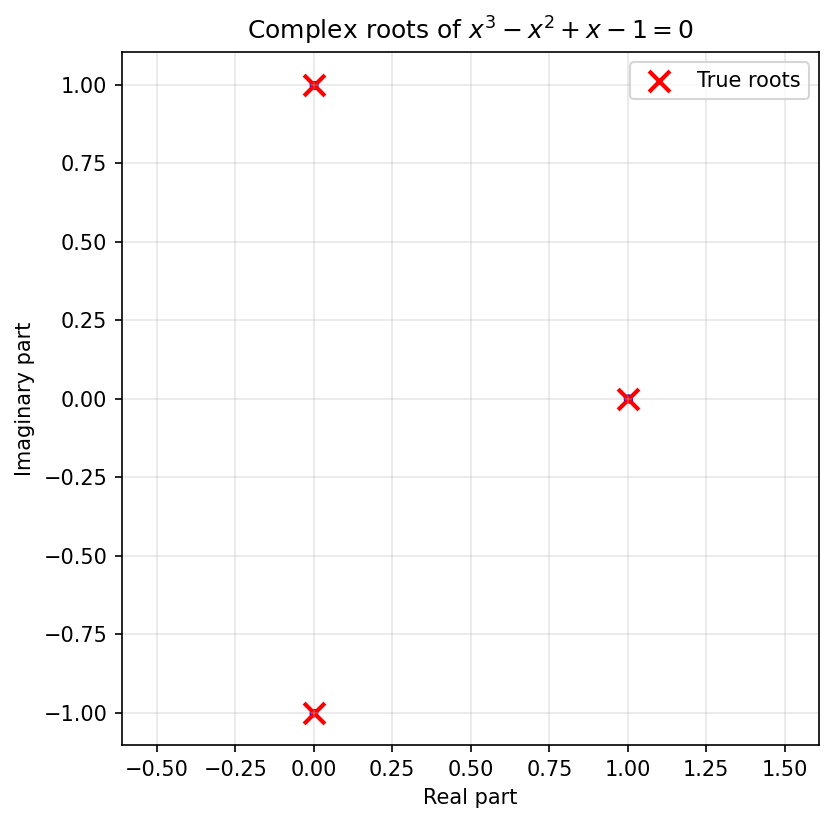

In [6]:
# Fit GMM and find roots
gmm, info = best_gmm(data, verbose=False)
print(f"Best model: {info['best_k']} components")

# Condition on output = [0, 0] (real and imaginary parts both zero)
c = gmm.condition([2, 3], [[0.0, 0.0]])

# Sample and plot
results = c.sample(1000)

plt.figure(figsize=(6, 6))
plt.scatter(results[:, 0], results[:, 1], c='blue', s=5, alpha=0.3)
plt.scatter([1, 0, 0], [0, 1, -1], c='red', s=100, marker='x', 
            linewidths=2, label='True roots')
plt.xlabel('Real part')
plt.ylabel('Imaginary part')
plt.title('Complex roots of $x^3 - x^2 + x - 1 = 0$')
plt.legend()
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
# Final timing and memory report
_end_time = time.time()
_end_memory_mb = _process.memory_info().rss / (1024 * 1024)
_elapsed_seconds = _end_time - _start_time

print("\n" + "=" * 70)
print("NOTEBOOK EXECUTION SUMMARY")
print("=" * 70)
print(f"Start time:      {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_start_time))}")
print(f"End time:        {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_end_time))}")
print(f"Elapsed time:    {_elapsed_seconds:.2f} seconds ({_elapsed_seconds/60:.2f} minutes)")
print("-" * 70)
print(f"Initial memory:  {_start_memory_mb:.2f} MB")
print(f"Final memory:    {_end_memory_mb:.2f} MB")
print(f"Memory change:   {_end_memory_mb - _start_memory_mb:+.2f} MB")
print("=" * 70)


NOTEBOOK EXECUTION SUMMARY
Start time:      2025-12-18 08:14:36
End time:        2025-12-18 08:14:37
Elapsed time:    0.99 seconds (0.02 minutes)
----------------------------------------------------------------------
Initial memory:  331.27 MB
Final memory:    413.22 MB
Memory change:   +81.95 MB
